In [3]:
# Code imports
from lib.opt_types import *
from lib.utils import *

# Image inpainting with proximal methods - 30 points + 2 bonus points

Image in-painting consists of reconstructing the missing parts of an image from a given incomplete image.

By exploiting some prior knowledge on the image, it is possible to in-paint images that have a large portion of their pixels missing. In this part of the homework, we are going to study different methods to achieve this goal.

We consider a subsampled image $\mathbf{b} = \mathbf{P}_{\Omega} \mathbf{x}$, where $\mathbf{P}_{\Omega} \in \mathbb{R}^{n \times p}$ is an operator that selects only few, $n \ll p := m^2$, pixels from the vectorized image $\mathbf{x} \in \mathbb{R}^p$. Our goal is to reconstruct the original image $\mathbf{x}$.

### Prior knowledge

Image inpainting is impossible without having some prior knowledge on the structure of the true image $\mathbf{x}$. 

We will explore and compare the following prior assumptions we can make on the true image: 
>  **Assumption**: There exists a orthonormal basis $\mathbf{W} \in \mathbb{R}^{p\times p}$ such that $\mathbf{x}$ can be sparsely represented in that basis, i.e, $\mathbf{W} \mathbf{x}$ is a vector with few non-zero coefficients. Writing $\boldsymbol\alpha=\mathbf W\mathbf x$, we have $\mathbf x=\mathbf W^\top\boldsymbol\alpha$. We promote sparsity by penalizing $\|\boldsymbol\alpha\|_1$, a convex surrogate for the number of nonzero coefficients. We assume that this basis is known and corresponds to the _wavelet basis_. Under this assumption, the reconstruction problem corresponds to solving the following optimization problem:
$$
\min_{\mathbf{\alpha} \in \mathbb{R}^{p}} \underbrace{ \frac{1}{2}\|\mathbf{b} - \mathbf{P}_{\Omega} \mathbf{W}^T\mathbf{\alpha} \|_2^2}_{f_{\ell_1}(\mathbf{\alpha})} + \underbrace{\lambda_{\ell_1} \|\mathbf{\alpha}\|_1}_{g_{\ell_1}(\mathbf{\alpha})},
$$
where $\lambda_{\ell_1}$ is a coefficient we will need to choose.



# PART 1: Optimizing with an $\ell_1$ norm regularization

The optimization problem we are looking to solve have an objective function of the form:
$$
	 f(\mathbf{x}) + g(\mathbf{x}).
$$

These types of objectives are referred to as _composite objectives_ where one term, $f$, is smooth and differentiable and the other term $g$ is non-differentiable.

---

## Code structure:

Recall that we have been working with the `Function` type so far. We will augment this type to represent functions that are not differentiable:

- Given a `Function` `g` you can obtain a subgradient at a point `x` by calling `g.subgrad(x)`.

Moreover, since we are dealing with _composite_ problems with a an objective function that can be written `f + g`, we define the `CompositeFunction` type defined as
```python
@dataclass
class CompositeFunction:
    f: Function
    g: Function
```

The iterative schemes you will implement will receive a composite function that they can unpack as follows:

```python
def state_update(composite_function, state):
    f, g = composite_function

```

#### Question 1: (5 point)

A first approach to solve a non-smooth optimization problem can be to turn to subgradients. Review slide 42-44 of Lecture 6, and implement `SubG` with $\alpha_k = \frac{0.1}{\sqrt{k}}$, starting the counter at $k=1$.

In [4]:
@dataclass
class SubG_state(OptState):
    """
    State for the subgradient method on F(x) = f(x) + g(x).

    Attributes:
        x_k:   current iterate x_k
        k:     iteration counter (starts at 0)
        c:     constant in the step-size alpha_k = c / sqrt(k+1)
    """
    x_k: Vector
    k: int
    c: float
    pass


In [5]:
def SubG_update(composite_function, state):
    """
    Subgradient method update:

    x_{k+1} = x_k - alpha_k * ( grad f(x_k) + s_k ),
    where:
        grad f(x_k) = f.grad(x_k)
        s_k         in partial g(x_k)  ->  g.subgrad(x_k)
        alpha_k     = c / sqrt(k+1)

    Then increment the counter k -> k+1.
    """
    f, g = composite_function.f, composite_function.g

    x_k = state.x_k
    k = state.k
    c = state.c

    # Gradient of the smooth part
    grad_f = f.grad(x_k)

    # A subgradient of the non-smooth part
    subgrad_g = g.subgrad(x_k)

    # Total subgradient of F = f + g
    subgrad_F = grad_f + subgrad_g

    # Decreasing step-size: alpha_k = c / sqrt(k+1)
    alpha_k = c / np.sqrt(k + 1)

    # Update step
    x_next = x_k - alpha_k * subgrad_F

    # Increment iteration counter
    k_next = k + 1

    return SubG_state(x_k=x_next, k=k_next, c=c)

def SubG_initialize(composite_function, x_zero):
    """
    Initialize the state for SubG.

    Start from:
        x_0 = x_zero
        k_0 = 0
        c   = a positive constant (here chosen as 1.0, but can be tuned).

    Note: In more refined settings, c can be chosen based on estimates of L,
    the domain diameter, etc. For this homework, a simple constant is fine.
    """
    c = 1.0  # step-size constant; can be adjusted if needed
    return SubG_state(x_k=x_zero, k=0, c=c)
    


In [6]:
# Algorithm definition
SubG = OptAlgorithm(name="SubG", init_state=SubG_initialize, state_update=SubG_update)

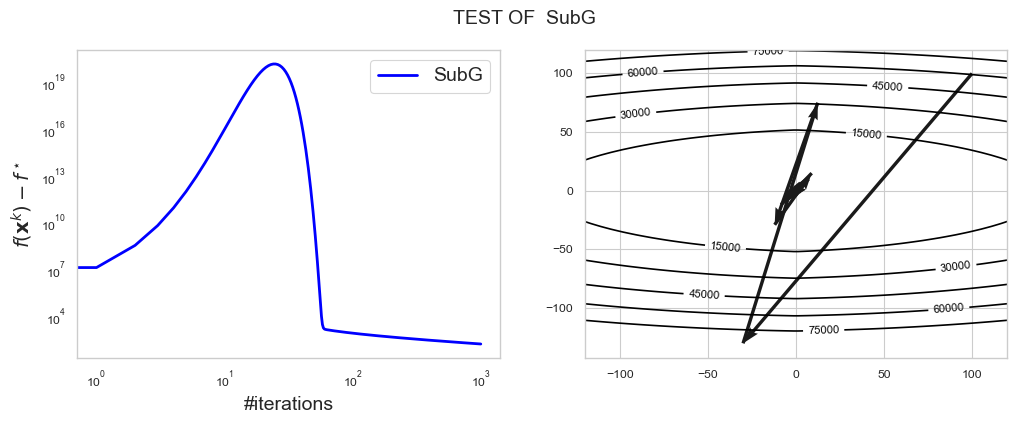

In [7]:
test_composite(SubG)


---

Another, more efficient approach, as we saw in Lecture 8, is to minimize such a function by using proximal gradient algorithms, provided that $g$ is _proximable_ (i.e., its proximal operator is efficient to evaluate). We recall the proximal operator of $g$ as the solution to the following convex problem:
$$
\mathrm{prox}_g(\mathbf{z}) := \mathrm{arg}\min_{\mathbf{y}\in\mathbb{R}^d}\{ g(\mathbf{y}) + \frac{1}{2}\Vert\mathbf{y} - \mathbf{z}\Vert_2^2\}.
$$

#### Question 2 (2 points)

Given $g_{\ell_1}: \mathbb{R}^p \rightarrow \mathbb{R}, \; g_{\ell_1}(\mathbf{x}) :=  \beta \|\mathbf{x}\|_1$ with $\beta\geq0$, show that its proximal function can be written as
    $$
    \mathrm{prox}_{\gamma g_{\ell_1}}(\mathbf{z}) = \max(|\mathbf{z}|-\beta \gamma,0) \circ \mathrm{sign}(\mathbf{z}), \; \text{for any }\mathbf{z} \in \mathbb{R}^p,\; \gamma \in \mathbb{R}_+
    $$
			where the operators $\max$, $\mathrm{sign}$ and $\lvert \cdot \lvert$ are applied coordinate-wise to the vector $\mathbf{z}$ and $\circ$ stands for $(\mathbf{x} \circ \mathbf{y})_i = x_i y_i$. Such a regularizer imposes sparsity on the solutions.


**ANSWER:** 

We consider $g_{\ell_1}(x) = \beta \|x\|_1$ with $\beta > 0$. By definition, the proximal operator of $g_{\ell_1}$ at $z \in \mathbb{R}^p$ is

$$
\operatorname{prox}_{\gamma g_{\ell_1}}(z)
= \arg\min_{x \in \mathbb{R}^p}
\left\{ \gamma \beta \|x\|_1 + \frac{1}{2}\|x - z\|_2^2 \right\}.
$$

Since both terms are separable across coordinates, the problem decouples into $p$ independent scalar problems:

$$
\min_{x_i \in \mathbb{R}}
\left\{ \gamma \beta |x_i| + \frac{1}{2}(x_i - z_i)^2 \right\},
\quad i = 1,\dots,p.
$$

For a fixed coordinate $i$, let $\phi_i(x_i) = \gamma \beta |x_i| + \frac{1}{2}(x_i - z_i)^2$. The optimality condition is $0 \in \partial \phi_i(x_i^\star)$. 

Using $\partial |x| = \{\operatorname{sign}(x)\}$ for $x \neq 0$ and $[-1,1]$ for $x = 0$, we can distinguish three cases:

- If $x_i^\star > 0$: $\partial |x_i^\star| = \{1\}$, so $0 = \gamma \beta + (x_i^\star - z_i)$, hence $x_i^\star = z_i - \gamma \beta$, which requires $z_i > \gamma \beta$.
- If $x_i^\star < 0$: $\partial |x_i^\star| = \{-1\}$, so $0 = -\gamma \beta + (x_i^\star - z_i)$, hence $x_i^\star = z_i + \gamma \beta$, which requires $z_i < -\gamma \beta$.
- If $x_i^\star = 0$: $\partial |x_i^\star| = [-1,1]$, and the condition becomes $0 \in \gamma \beta [-1,1] - z_i$, i.e. $|z_i| \le \gamma \beta$.

Combining the cases, we obtain

$$
\left[\operatorname{prox}_{\gamma g_{\ell_1}}(z)\right]_i
=
\begin{cases}
z_i - \gamma \beta & \text{if } z_i > \gamma \beta,\\[4pt]
0 & \text{if } |z_i| \le \gamma \beta,\\[4pt]
z_i + \gamma \beta & \text{if } z_i < -\gamma \beta.
\end{cases}
$$

Equivalently, in vector form,

$$
\operatorname{prox}_{\gamma g_{\ell_1}}(z)
= \operatorname{sign}(z) \odot \max\big(|z| - \gamma \beta,\, 0\big),
$$

where $\operatorname{sign}(\cdot)$, $|\cdot|$, and $\max(\cdot,0)$ are applied coordinate-wise. This is known as the soft-thresholding operator, which promotes sparsity in the solution.


#### Question 3 (1 point)
 Fill in the function `l1_prox` with the proximal operator of $g_{\ell_1}$.

In [8]:
def l1_prox(gamma, z, beta):

    """
    Proximal operator of g_{l1}(x) = beta * ||x||_1.

    prox_{gamma * g}(z) = sign(z) * max(|z| - gamma * beta, 0),
    applied coordinate-wise.

    Parameters:
        gamma: step-size (scalar > 0)
        z: input vector (numpy array)
        beta: l1 regularization parameter (scalar > 0)

    Returns:
        x: prox_{gamma * beta * ||.||_1}(z)
    """
    
    threshold = gamma * beta
    return np.sign(z) * np.maximum(np.abs(z) - threshold, 0.0)


#### Question 4 (4 points)

From here on, in order to speed-up the convergence of the optimization, let's assume that the function $f$ has been made to be $\mu$-strongly convex by the addition of an $\ell_2$ regularization term to the function $f$, while the $\ell_1$ term, $g$, has remained unchanged. As such, we must now utilize the strong-convexity versions of the composite optimization algorithms.

Using the information in Lecture 7 slide 21 fill in the codes of the method $\text{ISTA}_\mu$. In the provided quadratic test, $\beta=30$. Use `g.prox(alpha, z)` to apply the proximal operator of the supplied regularizer, including its weight.

In [9]:
@dataclass
class ISTA_state(OptState):
    """
    State for ISTA (proximal gradient method) on F(x) = f(x) + g(x).

    Attributes:
        x_k:   current iterate x_k
        alpha: step-size (constant, chosen as 1 / L where L is the smoothness constant of f)
    """    
    x_k: Vector
    alpha: float  # step-size


In [10]:
def ISTA_update(composite_function, state):
    """
    ISTA update:

    y_k = x_k - alpha * grad f(x_k)
    x_{k+1} = prox_{alpha * g}(y_k)

    where prox_{alpha * g} is applied via g.prox(alpha, y_k).
    """

    f = composite_function.f
    g = composite_function.g

    x_k = state.x_k
    alpha = state.alpha

    # Gradient step on the smooth part f
    grad_f = f.grad(x_k)
    y_k = x_k - alpha * grad_f

    # Proximal step on the non-smooth part g
    x_next = g.prox(alpha, y_k)

    return ISTA_state(x_k=x_next, alpha=alpha)

def ISTA_initialize(composite_function, x_zero):
    """
    Initialize ISTA state:

    x_0 = x_zero
    alpha = 1 / L, where L is the gradient-Lipschitz constant of f.
    """    

    f = composite_function.f

    # Step-size based on smoothness of f
    alpha = 1.0 / f.lips_grad

    return ISTA_state(x_k=x_zero, alpha=alpha)


In [11]:
ISTA = OptAlgorithm(name="ISTA", init_state= ISTA_initialize, state_update=ISTA_update)

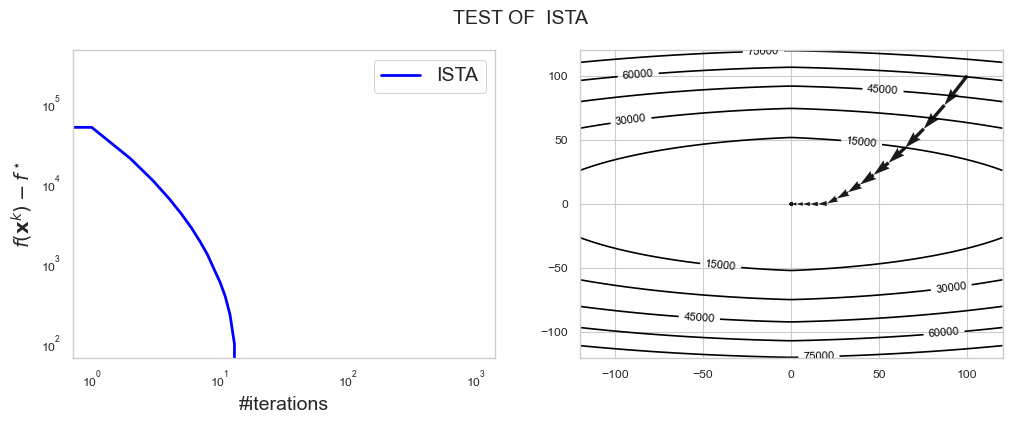

In [12]:
test_composite(ISTA, prox=l1_prox)


#### Question 5  (7 points)

Using the information in Lecture 7 slide 21 fill in the codes of the method $\text{FISTA}_\mu$.

In [14]:
@dataclass 
class FISTA_state(OptState):
    x_k: Vector
    y_k: Vector
    alpha_k: float
    c_f: float

In [13]:
import numpy

def FISTA_update(composite_function, state):

    f, g = composite_function

    x_k = state.x_k
    y_k = state.y_k
    alpha_k = state.alpha_k
    c_f = state.c_f

    z_k = y_k - alpha_k * f.grad(y_k)
    x_next = g.prox(alpha_k, z_k)

    momentum = (numpy.sqrt(c_f) - 1.0) / (numpy.sqrt(c_f) + 1.0)
    y_next = x_next + momentum * (x_next - x_k)

    return FISTA_state(
        x_k=x_next,
        y_k=y_next,
        alpha_k=alpha_k,
        c_f=c_f
    )



def FISTA_initialize(composite_function, x_zero):
    
    f, _ = composite_function

    alpha_k = 1.0 / f.lips_grad
    c_f = f.lips_grad / f.strng_cvx

    return FISTA_state(
        x_k=x_zero,
        y_k=x_zero.copy(),
        alpha_k=alpha_k,
        c_f=c_f
    )


In [15]:
FISTA = OptAlgorithm(name="FISTA", init_state= FISTA_initialize, state_update=FISTA_update)

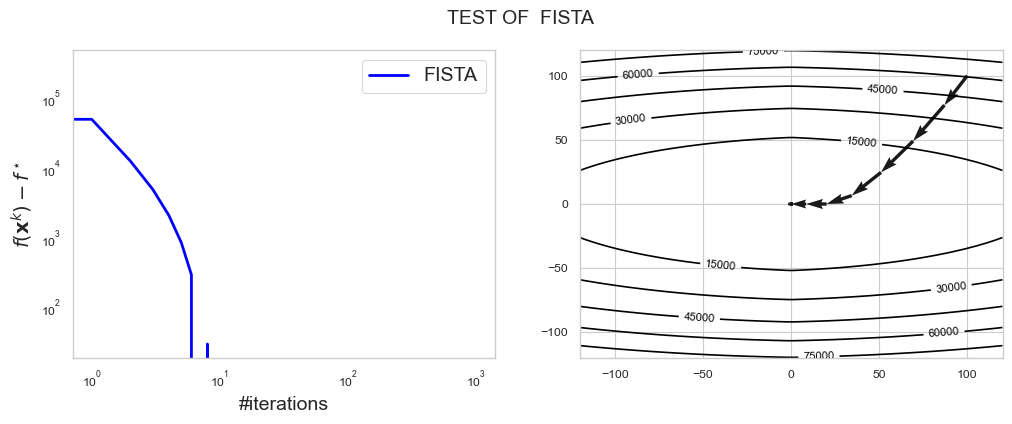

In [16]:
test_composite(FISTA, prox=l1_prox)


Unlike ISTA, FISTA is not necessarily monotone: its momentum/extrapolation step can slightly overshoot near the minimizer, causing occasional small increases in the objective value while still achieving faster overall convergence.

#### Question 6  (2 points)

Compare the convergence rates of the three methods and analyze whether the observed results align with their theoretical bounds.

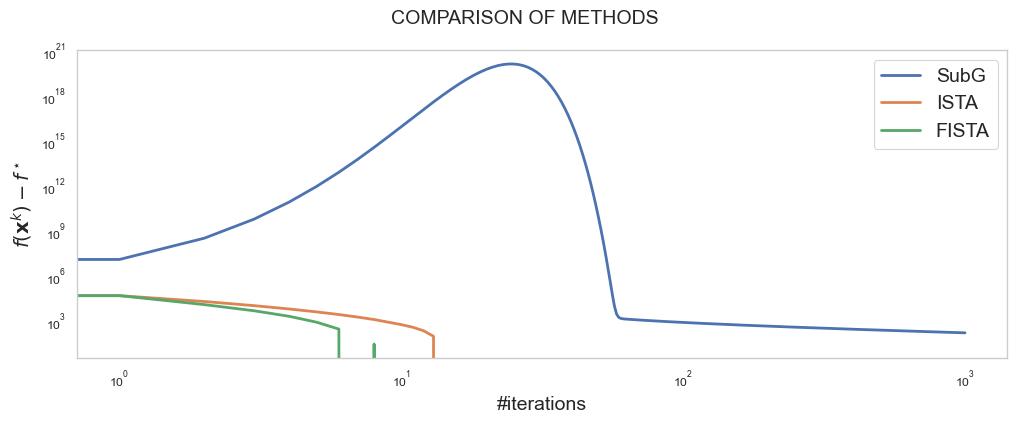

In [21]:
list_of_methods = [SubG, ISTA, FISTA]
compare_composite(list_of_methods, prox=l1_prox)


**ANSWER:** 

Let

$$
F(x) = f(x) + g(x),
$$

where $f$ is $L_f$-smooth and $\mu_f$-strongly convex, while $g$ is convex and proximally tractable.

The three methods use increasingly more information about the structure of the problem. SubG treats the objective as a generic non-smooth convex function and performs the update

$$
x_{k+1} = x_k - \alpha_k d_k,
\qquad
d_k \in \partial F(x_k).
$$

With a decreasing step-size of order $\alpha_k = O(1/\sqrt{k})$, the corresponding general guarantee is

$$
\min_{0 \leq i \leq k} F(x_i) - F^\star
=
O\left(\frac{1}{\sqrt{k}}\right).
$$

This is the slowest rate among the methods considered here. In the experiment, SubG performs significantly worse than the proximal methods: the objective gap initially increases by several orders of magnitude and then decreases only slowly. This illustrates that subgradient methods can be quite sensitive to the scaling of the problem and to the choice of the step-size constant. The theoretical result also relies on bounded subgradients and a suitably chosen step-size.

ISTA exploits the composite form of the objective. Instead of using a subgradient of $g$, it applies the proximal operator:

$$
x_{k+1}
=
\operatorname{prox}_{\alpha_k g}
\left(x_k - \alpha_k \nabla f(x_k)\right),
\qquad
\alpha_k = \frac{1}{L_f}.
$$

Since $f$ is strongly convex, we define

$$
c_f = \frac{L_f}{\mu_f}.
$$

For this setting, ISTA converges linearly, with the bound

$$
F(x_k) - F^\star
\leq
\frac{L_f}{2}
\left(
\frac{c_f - 1}{c_f + 1}
\right)^{2k}
\|x_0 - x^\star\|_2^2.
$$

This faster behavior is clearly visible in the plot: ISTA rapidly reduces the objective gap and reaches the target accuracy after approximately $10$--$12$ iterations.

FISTA adds an extrapolation step to the proximal-gradient method. Its updates are

$$
x_{k+1}
=
\operatorname{prox}_{\alpha_k g}
\left(y_k - \alpha_k \nabla f(y_k)\right),
$$

and

$$
y_{k+1}
=
x_{k+1}
+
\frac{\sqrt{c_f}-1}{\sqrt{c_f}+1}
\left(x_{k+1}-x_k\right).
$$

For a strongly convex $f$, FISTA also has a linear convergence guarantee:

$$
F(x_k) - F^\star
\leq
\frac{L_f}{2}
\left(
1-\sqrt{\frac{\mu_f}{L_f}}
\right)^k
\|x_0-x^\star\|_2^2.
$$

The dependence on the condition number is better than for ISTA, which explains why FISTA reaches the target accuracy first, after approximately $7$--$8$ iterations. The small rise in the FISTA curve near convergence is not unexpected: the extrapolation step may temporarily increase the objective value, even though it improves the overall convergence speed.

Overall, the numerical results are qualitatively consistent with the theoretical comparison: SubG is the slowest method, ISTA is much faster because it uses the proximal operator of $g$, and FISTA provides the best practical convergence rate among the three methods.

# Part 2: Application


We have now implemented multiple methods that can solve composite optimization problems. We will now apply them to an image inpainting problem.


Take a natural image, or better a picture of you, and place it in the same directory as this notebook.

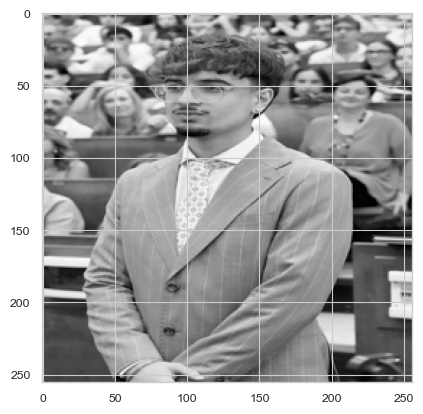

In [ ]:
from lib.inpainting import *

image = load("test_pic.jpg")  # FILL: replace with your image filename

With this image in hand, let us subsample it and try to reconstruct the original.

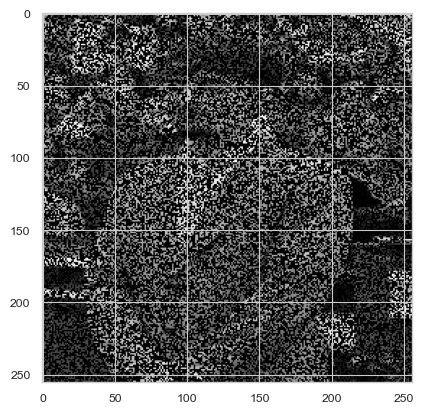

In [27]:
subsampled = show_subsampled(image)

For the rest of the questions, to ensure the function is 
$\mu$-strongly convex, we need to add an $\ell_2$ regularization term to it. As a result, we change the definition of $f_{\ell_1}(\mathbf{\alpha})$ as follows:
$$
    f_{\ell_1}(\mathbf{\alpha}) = \frac{1}{2}\|\mathbf{b} - \mathbf{P}_{\Omega} \mathbf{W}^T\mathbf{\alpha} \|_2^2 + \frac{1}{2}\mu \|\mathbf{\alpha}\|_2^2 
    $$

and the composite function becomes:
 $$
    \min_{\mathbf{\alpha} \in \mathbb{R}^{p}} \underbrace{ \frac{1}{2}\|\mathbf{b} - \mathbf{P}_{\Omega} \mathbf{W}^T\mathbf{\alpha} \|_2^2 + \frac{1}{2}\mu \|\mathbf{\alpha}\|_2^2 }_{f_{\ell_1}(\mathbf{\alpha})} + \underbrace{\lambda_{\ell_1} \|\mathbf{\alpha}\|_1}_{g_{\ell_1}(\mathbf{\alpha})},
    $$

By adding this regularization, we ensure better properties for optimization, making the solution more stable and well-behaved.

In the following cells we will define the optimization problems we need to solve to perform the reconstruction.

- We provide you with a function `P` that acts like the matrix $\mathbf{P}_{\Omega}$. That is, given a vector `x`, it returns a subsampled vector `P(x)` that corresponds to $\mathbf{P}_{\Omega} \mathbf{x}$. We also give you `P_T` which acts like $\mathbf{P}^\top$.
- We provide you with a function `W` and `W_T` that act like the matrix $\mathbf{W}$ and $\mathbf{W^\top}$ respectively. That is, for a vector `x`, `W(x)` and `W_T(x)` return $\mathbf{W}\mathbf{x}$ and $\mathbf{W^\top}\mathbf{x}$ respectively.

__(a)__ (1 point) Using these provided functions, define the observed variable `b` in the cell below.

In [28]:
from lib.inpainting import P, P_T, W, W_T

x = image.reshape(-1) #flattened image

b = P(x)

__(b)__ (1 point) Now define the function `f_l1` as described earlier in the problem text.

In [29]:
mu = 1e-4 # Desired strong convexity of f
def f_l1(alpha):

    residual = b - P(W_T(alpha))
    
    return 0.5 * np.linalg.norm(residual)**2 + 0.5 * mu * np.linalg.norm(alpha)**2

__(c)__ (1 point) Write the gradient of $f_{\ell_1}(\mathbf{\alpha})$.

In [31]:
def grad_f_l1(alpha):

    residual = P(W_T(alpha)) - b
    
    return W(P_T(residual)) + mu * alpha


__(d)__ (1 points) Find the Lipschitz constant of $\nabla_\mathbf{\alpha} f_{\ell_1}(\mathbf{\alpha})$ analytically and fill it in the cell below. 

**ANSWERS:**

We have

$$
f_{\ell_1}(\boldsymbol{\alpha})
=
\frac{1}{2}
\left\|
\mathbf{b}
-
\mathbf{P}_{\Omega}\mathbf{W}^{\top}\boldsymbol{\alpha}
\right\|_2^2
+
\frac{\mu}{2}
\|\boldsymbol{\alpha}\|_2^2.
$$

Its gradient is

$$
\nabla_{\boldsymbol{\alpha}} f_{\ell_1}(\boldsymbol{\alpha})
=
\mathbf{W}\mathbf{P}_{\Omega}^{\top}
\left(
\mathbf{P}_{\Omega}\mathbf{W}^{\top}\boldsymbol{\alpha}
-
\mathbf{b}
\right)
+
\mu\boldsymbol{\alpha}.
$$

Since $f_{\ell_1}$ is quadratic, its Hessian is constant and given by

$$
\nabla^2_{\boldsymbol{\alpha}} f_{\ell_1}(\boldsymbol{\alpha})
=
\mathbf{W}\mathbf{P}_{\Omega}^{\top}
\mathbf{P}_{\Omega}
\mathbf{W}^{\top}
+
\mu\mathbf{I}.
$$

The Lipschitz constant of the gradient is the spectral norm of the Hessian:

$$
L_{f_{\ell_1}}
=
\left\|
\mathbf{W}\mathbf{P}_{\Omega}^{\top}
\mathbf{P}_{\Omega}
\mathbf{W}^{\top}
+
\mu\mathbf{I}
\right\|_2.
$$

The subsampling operator $\mathbf{P}_{\Omega}$ selects pixels. Therefore,

$$
\mathbf{P}_{\Omega}^{\top}\mathbf{P}_{\Omega}
$$

is a diagonal matrix with diagonal entries equal to either $0$ or $1$. Hence,

$$
\left\|
\mathbf{P}_{\Omega}^{\top}\mathbf{P}_{\Omega}
\right\|_2
=
1.
$$

Moreover, $\mathbf{W}$ is orthonormal, so

$$
\mathbf{W}^{\top}\mathbf{W}
=
\mathbf{W}\mathbf{W}^{\top}
=
\mathbf{I},
\qquad
\|\mathbf{W}\|_2
=
\|\mathbf{W}^{\top}\|_2
=
1.
$$

Thus,

$$
\left\|
\mathbf{W}\mathbf{P}_{\Omega}^{\top}
\mathbf{P}_{\Omega}
\mathbf{W}^{\top}
\right\|_2
=
1.
$$

The eigenvalues of

$$
\mathbf{W}\mathbf{P}_{\Omega}^{\top}
\mathbf{P}_{\Omega}\mathbf{W}^{\top}
$$

are $0$ or $1$. Adding $\mu\mathbf{I}$ shifts all eigenvalues by $\mu$, so the largest eigenvalue is $1+\mu$. Therefore,

$$
L_{f_{\ell_1}} = 1 + \mu.
$$


In [32]:
lips_grad_f_l1 = 1.0 + mu


We have all the necessary ingredients to define the smooth part of our composite objective:

In [33]:
f_l1 = Function(f = f_l1, grad=grad_f_l1, lips_grad = lips_grad_f_l1, strng_cvx=mu)

For the non-smooth term, `l1` represents the unweighted $\ell_1$ norm. `Regularizer` applies the weight `lmda` to both the function value and its proximal operator, reusing `l1_prox` with $\beta=1$:

In [34]:
l1 = Function(f = lambda x: np.sum(np.abs(x), axis=0), prox=lambda gamma, z: l1_prox(gamma, z, beta=1))

g_l1 = Regularizer(l1)

In [35]:
composite_objective = CompositeFunction(f=f_l1, g=g_l1)

With the objective defined, we provide you with a function with the following signature:
```python
solve_composite(method: OptAlgorithm, composite_objective: CompositeFunction, lmda: float, max_iterations: int) -> Vector
```

In other words, the function takes an optimization algorithm `method`, a CompositeFunction `composite_objective`, a regularization parameter `lmda` and a number of iterations `max_iterations` and returns a vector which is the last iterate given by the `method`.



In [36]:
from lib.inpainting import solve_composite

__(e)__ (5 points) Using `solve_composite` reconstruct the subsampled image. Recall that the composite problem solves for $\mathbf{\alpha}$ so you need to convert the output back to an image and visualize it.

Select a reasonable value for `lmda`.

**Bonus (2 points).** Using `solve_composite` and the `PSNR` metric, find the best value for `lmda`.

In [ ]:
lmda = ...  # FILL
out = ...  # FILL: run your chosen method.
flat_image_out = ...  # FILL
image_out = ...  # FILL


In [ ]:
show(true = image, subsampled=subsampled, estimated=image_out)

In [ ]:
# FILL: optional bonus parameter search using PSNR.
